<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/FLOW_FORCASTING.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


===== BASELINE (Original Forecast) =====
MAE  : 15.82
RMSE : 20.15
MAPE : 19.96%

===== ML IMPROVED MODEL =====
MAE  : 20.34
RMSE : 26.59
MAPE : 25.03%

===== IMPROVEMENT =====
MAE improvement  : -28.61%
RMSE improvement : -31.94%
MAPE improvement : -25.38%

Saved: flow_prediction_results.xlsx


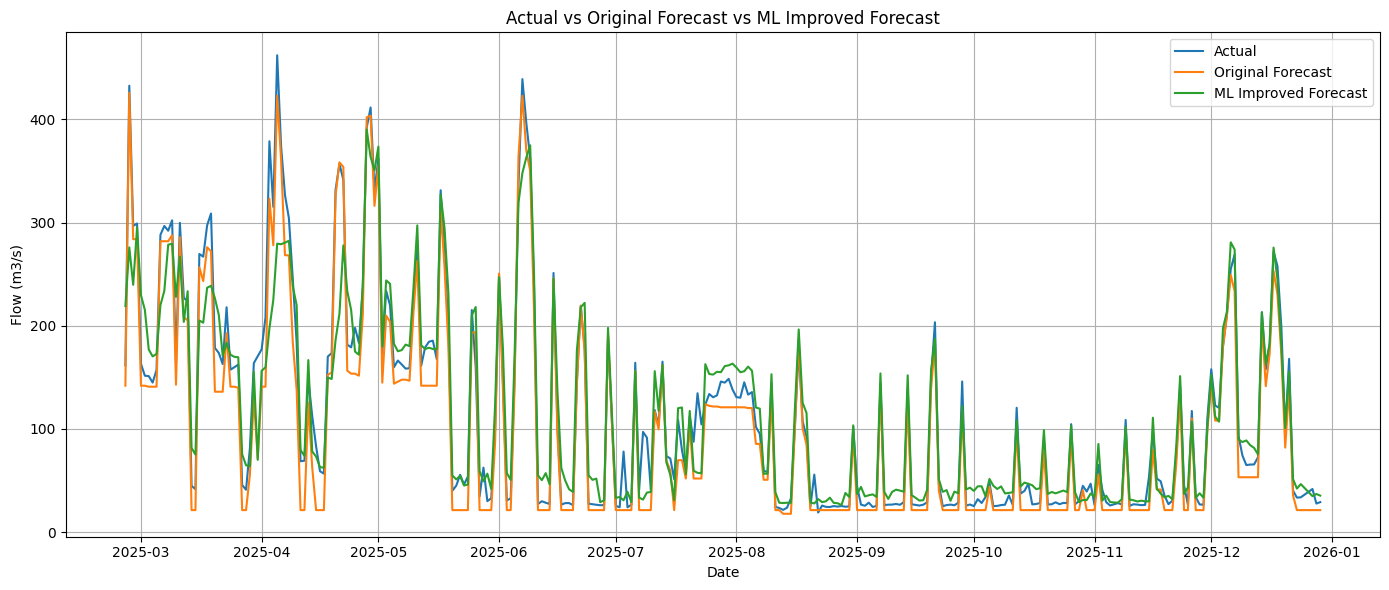


===== TOP 20 FEATURES =====
                             Feature  Importance
0         Incoming Flow Today (m3/s)    0.942614
3                          dayofyear    0.010922
6                        actual_lag1    0.010898
4                         weekofyear    0.008312
13             pred_today_error_prev    0.006931
10                 actual_roll3_mean    0.002901
11                 actual_roll7_mean    0.002714
7                        actual_lag2    0.001672
8                        actual_lag3    0.001648
1      Incoming Flow Tomorrow (m3/s)    0.001384
9                        actual_lag7    0.001124
23  Weather at Report Time Temp (°C)    0.000975
20                 rain_signal_count    0.000782
12                  actual_roll3_std    0.000765
22                clear_signal_count    0.000628
27           Day +3 Temperature (°C)    0.000581
5                          dayofweek    0.000579
16                temp_min_available    0.000567
18        temp_change_d3_minus_today    

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# =========================
# 1. LOAD DATA
# =========================
file_path = "Flow_predict.xlsx"
df = pd.read_excel(file_path)

# -------------------------
# Change these names only if needed
# -------------------------
COLUMN_MAP = {
    "date": "Report Date",
    "pred_today": "Incoming Flow Today (m3/s)",
    "pred_tomorrow": "Incoming Flow Tomorrow (m3/s)",
    "actual": "actual incoming flow",

    # weather / temperature columns
    "weather_now_temp": "Weather at Report Time Temp (°C)",
    "weather_now_climate": "Weather at Report Time Climate",

    "today_temp": "Today Temperature (°C)",
    "today_climate": "Today Climate Status",

    "d1_date": "Day +1 Date",
    "d1_temp": "Day +1 Temperature (°C)",
    "d1_climate": "Day +1 Climate Status",

    "d2_date": "Day +2 Date",
    "d2_temp": "Day +2 Temperature (°C)",
    "d2_climate": "Day +2 Climate Status",

    "d3_date": "Day +3 Date",
    "d3_temp": "Day +3 Temperature (°C)",
    "d3_climate": "Day +3 Climate Status",
}

# Keep only columns that really exist in your file
existing_cols = [v for v in COLUMN_MAP.values() if v in df.columns]
df = df[existing_cols].copy()

# Standardize datetime columns
for key in ["date", "d1_date", "d2_date", "d3_date"]:
    col = COLUMN_MAP.get(key)
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# Sort by date
if COLUMN_MAP["date"] in df.columns:
    df = df.sort_values(COLUMN_MAP["date"]).reset_index(drop=True)

# =========================
# 2. BASIC CLEANING
# =========================
# Remove rows with missing target
df = df[df[COLUMN_MAP["actual"]].notna()].copy()

# =========================
# 3. FEATURE ENGINEERING
# =========================
date_col = COLUMN_MAP["date"]
actual_col = COLUMN_MAP["actual"]
pred_today_col = COLUMN_MAP["pred_today"]
pred_tomorrow_col = COLUMN_MAP["pred_tomorrow"]

# Time features
df["month"] = df[date_col].dt.month
df["dayofyear"] = df[date_col].dt.dayofyear
df["weekofyear"] = df[date_col].dt.isocalendar().week.astype(float)
df["dayofweek"] = df[date_col].dt.dayofweek

# Lag features from actual flow
df["actual_lag1"] = df[actual_col].shift(1)
df["actual_lag2"] = df[actual_col].shift(2)
df["actual_lag3"] = df[actual_col].shift(3)
df["actual_lag7"] = df[actual_col].shift(7)

# Rolling features from actual flow
df["actual_roll3_mean"] = df[actual_col].rolling(3).mean().shift(1)
df["actual_roll7_mean"] = df[actual_col].rolling(7).mean().shift(1)
df["actual_roll3_std"] = df[actual_col].rolling(3).std().shift(1)

# Prediction error history (if using today forecast as baseline)
df["pred_today_error_prev"] = (df[actual_col] - df[pred_today_col]).shift(1)

# Temperature aggregate features if available
temp_cols = []
for key in ["weather_now_temp", "today_temp", "d1_temp", "d2_temp", "d3_temp"]:
    col = COLUMN_MAP.get(key)
    if col in df.columns:
        temp_cols.append(col)

if len(temp_cols) > 0:
    df["temp_mean_available"] = df[temp_cols].mean(axis=1)
    df["temp_max_available"] = df[temp_cols].max(axis=1)
    df["temp_min_available"] = df[temp_cols].min(axis=1)

# Forecast temperature trend if day+1,+2,+3 available
if all(COLUMN_MAP[k] in df.columns for k in ["today_temp", "d1_temp", "d2_temp", "d3_temp"]):
    df["temp_3day_ahead_mean"] = df[
        [COLUMN_MAP["d1_temp"], COLUMN_MAP["d2_temp"], COLUMN_MAP["d3_temp"]]
    ].mean(axis=1)
    df["temp_change_d3_minus_today"] = df[COLUMN_MAP["d3_temp"]] - df[COLUMN_MAP["today_temp"]]

# Climate count features
climate_cols = []
for key in ["weather_now_climate", "today_climate", "d1_climate", "d2_climate", "d3_climate"]:
    col = COLUMN_MAP.get(key)
    if col in df.columns:
        climate_cols.append(col)

def climate_count(row, words):
    c = 0
    for col in climate_cols:
        val = str(row[col]).lower() if pd.notna(row[col]) else ""
        if any(w in val for w in words):
            c += 1
    return c

if len(climate_cols) > 0:
    df["snow_signal_count"] = df.apply(lambda r: climate_count(r, ["snow", "sleet"]), axis=1)
    df["rain_signal_count"] = df.apply(lambda r: climate_count(r, ["rain", "shower"]), axis=1)
    df["fog_signal_count"] = df.apply(lambda r: climate_count(r, ["fog", "mist", "hazy"]), axis=1)
    df["clear_signal_count"] = df.apply(lambda r: climate_count(r, ["sunny", "clear", "slightly cloudy", "partly cloudy"]), axis=1)

# Optional: tomorrow actual target model
# If you want to predict NEXT DAY actual flow:
df["target_next_day_actual"] = df[actual_col].shift(-1)

# =========================
# 4. SELECT MODEL TARGET
# =========================
# A) For today's actual flow correction:
TARGET = actual_col
BASELINE = pred_today_col

# B) If later you want next-day forecast model, use:
# TARGET = "target_next_day_actual"
# BASELINE = pred_tomorrow_col

# Remove rows with missing target AND baseline predictions
df_model = df[df[TARGET].notna() & df[BASELINE].notna()].copy()

# =========================
# 5. FEATURE LIST
# =========================
candidate_features = [
    pred_today_col,
    pred_tomorrow_col,

    "month", "dayofyear", "weekofyear", "dayofweek",

    "actual_lag1", "actual_lag2", "actual_lag3", "actual_lag7",
    "actual_roll3_mean", "actual_roll7_mean", "actual_roll3_std",
    "pred_today_error_prev",

    "temp_mean_available", "temp_max_available", "temp_min_available",
    "temp_3day_ahead_mean", "temp_change_d3_minus_today",

    "snow_signal_count", "rain_signal_count", "fog_signal_count", "clear_signal_count",

    COLUMN_MAP["weather_now_temp"],
    COLUMN_MAP["today_temp"],
    COLUMN_MAP["d1_temp"],
    COLUMN_MAP["d2_temp"],
    COLUMN_MAP["d3_temp"],

    COLUMN_MAP["weather_now_climate"],
    COLUMN_MAP["today_climate"],
    COLUMN_MAP["d1_climate"],
    COLUMN_MAP["d2_climate"],
    COLUMN_MAP["d3_climate"],
]

feature_cols = [c for c in candidate_features if c in df_model.columns]

X = df_model[feature_cols].copy()
y = df_model[TARGET].copy()

# Separate numeric / categorical
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# =========================
# 6. PREPROCESS + MODEL
# =========================
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=3,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

# =========================
# 7. TIME SERIES VALIDATION
# =========================
tscv = TimeSeriesSplit(n_splits=5)

baseline_mae = []
baseline_rmse = []
baseline_mape = []

ml_mae = []
ml_rmse = []
ml_mape = []

all_dates = []
all_y_true = []
all_baseline_pred = []
all_ml_pred = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    pipeline.fit(X_train, y_train)
    y_pred_ml = pipeline.predict(X_test)

    # baseline = existing flow forecast
    baseline_test = df_model.iloc[test_idx][BASELINE].values

    # metrics baseline
    baseline_mae.append(mean_absolute_error(y_test, baseline_test))
    baseline_rmse.append(np.sqrt(mean_squared_error(y_test, baseline_test)))
    baseline_mape.append(mean_absolute_percentage_error(y_test, baseline_test) * 100)

    # metrics ML
    ml_mae.append(mean_absolute_error(y_test, y_pred_ml))
    ml_rmse.append(np.sqrt(mean_squared_error(y_test, y_pred_ml)))
    ml_mape.append(mean_absolute_percentage_error(y_test, y_pred_ml) * 100)

    all_dates.extend(df_model.iloc[test_idx][date_col].tolist())
    all_y_true.extend(y_test.tolist())
    all_baseline_pred.extend(baseline_test.tolist())
    all_ml_pred.extend(y_pred_ml.tolist())

# =========================
# 8. RESULTS
# =========================
print("\n===== BASELINE (Original Forecast) =====")
print(f"MAE  : {np.mean(baseline_mae):.2f}")
print(f"RMSE : {np.mean(baseline_rmse):.2f}")
print(f"MAPE : {np.mean(baseline_mape):.2f}%")

print("\n===== ML IMPROVED MODEL =====")
print(f"MAE  : {np.mean(ml_mae):.2f}")
print(f"RMSE : {np.mean(ml_rmse):.2f}")
print(f"MAPE : {np.mean(ml_mape):.2f}%")

improve_mae = 100 * (np.mean(baseline_mae) - np.mean(ml_mae)) / np.mean(baseline_mae)
improve_rmse = 100 * (np.mean(baseline_rmse) - np.mean(ml_rmse)) / np.mean(baseline_rmse)
improve_mape = 100 * (np.mean(baseline_mape) - np.mean(ml_mape)) / np.mean(baseline_mape)

print("\n===== IMPROVEMENT =====")
print(f"MAE improvement  : {improve_mae:.2f}%")
print(f"RMSE improvement : {improve_rmse:.2f}%")
print(f"MAPE improvement : {improve_mape:.2f}%")

# =========================
# 9. SAVE COMPARISON TABLE
# =========================
results_df = pd.DataFrame({
    "Date": all_dates,
    "Actual": all_y_true,
    "Original_Forecast": all_baseline_pred,
    "ML_Improved_Forecast": all_ml_pred
}).sort_values("Date")

results_df["Orig_Error"] = results_df["Actual"] - results_df["Original_Forecast"]
results_df["ML_Error"] = results_df["Actual"] - results_df["ML_Improved_Forecast"]

results_df.to_excel("flow_prediction_results.xlsx", index=False)
print("\nSaved: flow_prediction_results.xlsx")

# =========================
# 10. PLOT
# =========================
plt.figure(figsize=(14, 6))
plt.plot(results_df["Date"], results_df["Actual"], label="Actual")
plt.plot(results_df["Date"], results_df["Original_Forecast"], label="Original Forecast")
plt.plot(results_df["Date"], results_df["ML_Improved_Forecast"], label="ML Improved Forecast")
plt.xlabel("Date")
plt.ylabel("Flow (m3/s)")
plt.title("Actual vs Original Forecast vs ML Improved Forecast")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================
# 11. FEATURE IMPORTANCE
# =========================
# Fit on all available data for final interpretation
pipeline.fit(X, y)

# Extract feature names after preprocessing
ohe = pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_features) if len(categorical_features) > 0 else []
final_feature_names = numeric_features + list(cat_names)

importances = pipeline.named_steps["model"].feature_importances_
fi = pd.DataFrame({
    "Feature": final_feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print("\n===== TOP 20 FEATURES =====")
print(fi.head(20))

fi.head(20).to_excel("flow_feature_importance.xlsx", index=False)
print("Saved: flow_feature_importance.xlsx")